In [148]:
import os
import warnings

import matplotlib.pyplot as plt
from torchviz import make_dot

import numpy as np
import pandas as pd
import pytorch_lightning as pl
from lightning.pytorch import Trainer
import torch

from pytorch_forecasting import TemporalFusionTransformer, TimeSeriesDataSet
from pytorch_forecasting.data import TorchNormalizer
from pytorch_forecasting.metrics import QuantileLoss


import imageio
from matplotlib.pyplot import cm

os.chdir(os.getcwd())
warnings.filterwarnings("ignore")

In [149]:
plt.style.use(
    "https://raw.githubusercontent.com/emaldonadocruz/Publication_figure_style/master/Publication_figure_style.mplstyle"
)

In [150]:
data = pd.read_csv("../data/proc/test_final_kz.csv")
data["FECHA"] = pd.to_datetime(data["FECHA"] + "-5", format="%Y-%W-%w")
data.sort_values("FECHA", inplace=True)
data["time_idx"] = data.index + 1
data = data.rename(columns=lambda x: x.replace(".", "_"))
# replace spaces with underscores in column names
data.columns = data.columns.str.replace(" ", "_", regex=False)
# simple known-future calendar features (always available)
data["dow"] = data["FECHA"].dt.weekday.astype(int)
data["month"] = data["FECHA"].dt.month.astype(int)
data["group"] = "kz"
data["time_idx"] = data.groupby("group").cumcount()
data = data.drop(columns=["FECHA"])
data[data.select_dtypes(include=["int"]).columns] = data.select_dtypes(
    include=["int"]
).astype("int16")
data[data.select_dtypes(include=["float"]).columns] = data.select_dtypes(
    include=["float"]
).astype("float32")
data.head()

,RUTS_UNICOS_DIARIOS,CD,CFR,F,OTRO,CMA_CGM,COSCO,EVERGREEN,HAMBURG_SUD_/_COLUMBUS_LINE,HAPAG-LLOYD,...,Close_pct_change_XSICNEFE_Index__(R2),Close_pct_change_XSICNESE_Index__(L2),Close_pct_change_XSICUENE_Index__(R1),Close_pct_change_XSICUWFE_Index__(L1),Close_pct_change_XSICNEUE_Index__(L3),Close_pct_change_BDIY_Index__(R3),time_idx,dow,month,group
0,3.0,5.0,0.0,1.0,2.0,0.0,0.0,1.0,0.0,4.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0,4,7,kz
1,5.0,10.0,0.0,37.0,1.0,0.0,5.0,0.0,2.0,6.0,...,-0.022269,-0.018868,-0.108007,-0.032110,-0.015584,0.111852,1,4,8,kz
2,7.0,7.0,1.0,42.0,0.0,0.0,0.0,4.0,0.0,1.0,...,-0.002135,0.013462,-0.031315,0.000000,0.000000,0.062625,2,4,8,kz
3,5.0,20.0,74.0,33.0,0.0,0.0,0.0,0.0,0.0,74.0,...,-0.003566,-0.004744,0.058190,0.023697,-0.005805,-0.071473,3,4,8,kz
4,2.0,0.0,2.0,4.0,2.0,0.0,0.0,2.0,0.0,4.0,...,-0.002863,0.008580,0.044807,0.012346,0.000000,0.004727,4,4,8,kz


In [151]:
[x for x in data.columns if "XSICUENE" in x]

['XSICUENE_Index__(R1)', 'Close_pct_change_XSICUENE_Index__(R1)']

In [152]:
max_encoder_length = 8
target_col = 'XSICUENE_Index__(R1)'
max_epochs = 50
max_prediction_length = 8
time_varying_known_reals = ["time_idx", "dow", "month"]
feature_cols = [
    c
    for c in data.columns
    if c not in ["FECHA", target_col, "time_idx", "series", "dow", "month"]
]  # known into the future
time_varying_unknown_reals = [target_col] + feature_cols

(200.0, 220.0)

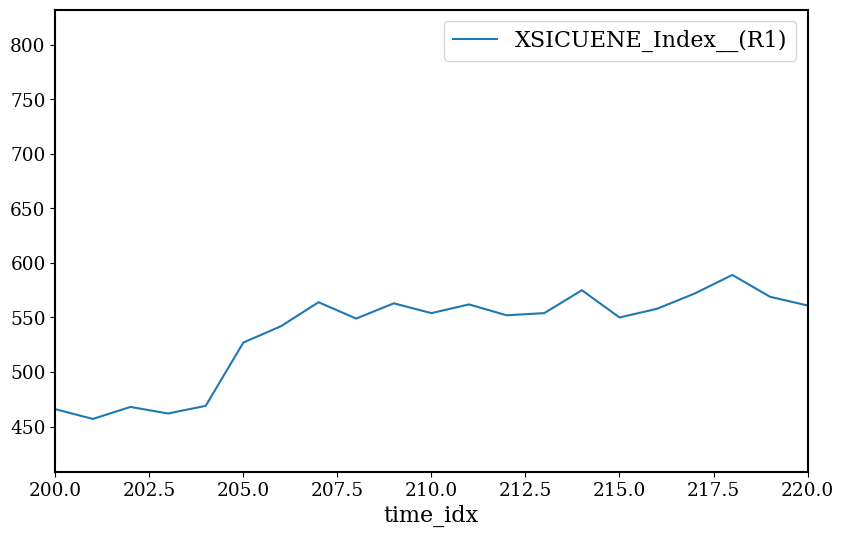

In [153]:
data.plot(x='time_idx', y=target_col)
plt.xlim(200, 220)

In [154]:
training_cutoff = (
    data["time_idx"].max() - 8
)  # max_prediction_length*len(data.well.unique())
training_cutoff

np.int16(223)

In [155]:
print("Missing values in group column:", data["group"].isnull().sum())
print(
    "Missing values in the filtered data:",
    data[data.time_idx <= training_cutoff]["group"].isnull().sum(),
)
filtered_data = data[data.time_idx <= training_cutoff]
print("Unique groups in filtered data:", filtered_data["group"].unique())
print("Group column dtype in filtered data:", filtered_data["group"].dtype)

Missing values in group column: 0
Missing values in the filtered data: 0
Unique groups in filtered data: ['kz']
Group column dtype in filtered data: object


In [156]:
# Check data types that might be causing issues
print("Data types of key columns:")
print(f"dow dtype: {data['dow'].dtype}, unique values: {sorted(data['dow'].unique())}")
print(
    f"month dtype: {data['month'].dtype}, unique values: {sorted(data['month'].unique())}"
)
print(f"time_idx dtype: {data['time_idx'].dtype}")
print(f"target dtype: {data[target_col].dtype}")

# Check for any other integer columns that might be inferred as categorical
int_cols = data.select_dtypes(include=["int64", "int32"]).columns.tolist()
print(f"Integer columns that might be inferred as categorical: {int_cols}")

Data types of key columns:
dow dtype: int16, unique values: [np.int16(4)]
month dtype: int16, unique values: [np.int16(1), np.int16(2), np.int16(3), np.int16(4), np.int16(5), np.int16(6), np.int16(7), np.int16(8), np.int16(9), np.int16(10), np.int16(11), np.int16(12)]
time_idx dtype: int16
target dtype: float32
Integer columns that might be inferred as categorical: []


In [157]:
data["group"] = 0

training = TimeSeriesDataSet(
    data[data.time_idx <= training_cutoff],
    time_idx="time_idx",
    target=target_col,
    group_ids=["group"],
    max_encoder_length=max_encoder_length,
    min_encoder_length=max_encoder_length,  # ensure full window
    max_prediction_length=8,
    min_prediction_length=2,
    time_varying_known_reals=time_varying_known_reals,
    time_varying_unknown_reals=time_varying_unknown_reals,
    static_categoricals=[],  # Explicitly specify no static categoricals
    static_reals=[],  # Explicitly specify no static reals
    time_varying_known_categoricals=[],  # Explicitly specify no time-varying categoricals
    time_varying_unknown_categoricals=[],  # Explicitly specify no time-varying categoricals
    target_normalizer=TorchNormalizer(),
    allow_missing_timesteps=True,
)

In [158]:
validation = TimeSeriesDataSet.from_dataset(
    training, data, predict=True, stop_randomization=True
)

# create dataloaders for model
batch_size = 128  # set this between 32 to 128
train_dataloader = training.to_dataloader(
    train=True,
    batch_size=batch_size,
)
val_dataloader = validation.to_dataloader(
    train=False,
    batch_size=batch_size * 2,
)

In [162]:
pl.seed_everything(42)

trainer = Trainer(
    max_epochs=max_epochs,
    devices=1,
    accelerator="cpu",
    enable_model_summary=True,
    enable_progress_bar=True,
    gradient_clip_val=0.1,
)

tft = TemporalFusionTransformer.from_dataset(
    training,
    learning_rate=1e-4,
    hidden_size=64,
    attention_head_size=4,
    dropout=0.2,
    hidden_continuous_size=64,
    output_size=7,
    loss=QuantileLoss(),
    reduce_on_plateau_patience=5,
)

Seed set to 42
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


In [163]:
trainer.fit(
    tft,
    train_dataloaders=train_dataloader,
    val_dataloaders=val_dataloader,
)


   | Name                               | Type                            | Params | Mode 
------------------------------------------------------------------------------------------------
0  | loss                               | QuantileLoss                    | 0      | train
1  | logging_metrics                    | ModuleList                      | 0      | train
2  | input_embeddings                   | MultiEmbedding                  | 0      | train
3  | prescalers                         | ModuleDict                      | 16.9 K | train
4  | static_variable_selection          | VariableSelectionNetwork        | 0      | train
5  | encoder_variable_selection         | VariableSelectionNetwork        | 2.8 M  | train
6  | decoder_variable_selection         | VariableSelectionNetwork        | 51.5 K | train
7  | static_context_variable_selection  | GatedResidualNetwork            | 16.8 K | train
8  | static_context_initial_hidden_lstm | GatedResidualNetwork            | 16.8 K 

Epoch 49: 100%|██████████| 1/1 [00:00<00:00,  2.51it/s, v_num=20, train_loss_step=28.90, val_loss=24.50, train_loss_epoch=28.90]

`Trainer.fit` stopped: `max_epochs=50` reached.


Epoch 49: 100%|██████████| 1/1 [00:00<00:00,  2.03it/s, v_num=20, train_loss_step=28.90, val_loss=24.50, train_loss_epoch=28.90]


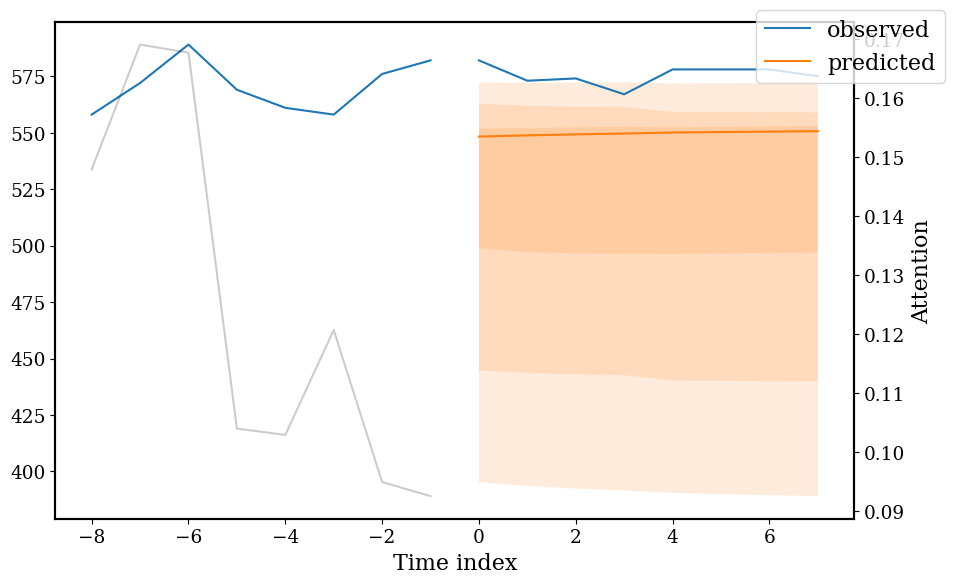

In [164]:
# Grab one batch & visualize
tft.eval()
with torch.inference_mode():
    batch = next(iter(val_dataloader))
    x = batch[0]
    out = tft(x)
    tft.plot_prediction(x, out, idx=0)  # change idx to view different series

Input shape: torch.Size([1, 8, 132])
Target shape: torch.Size([1, 8])
Predictions shape: torch.Size([1, 8, 7])


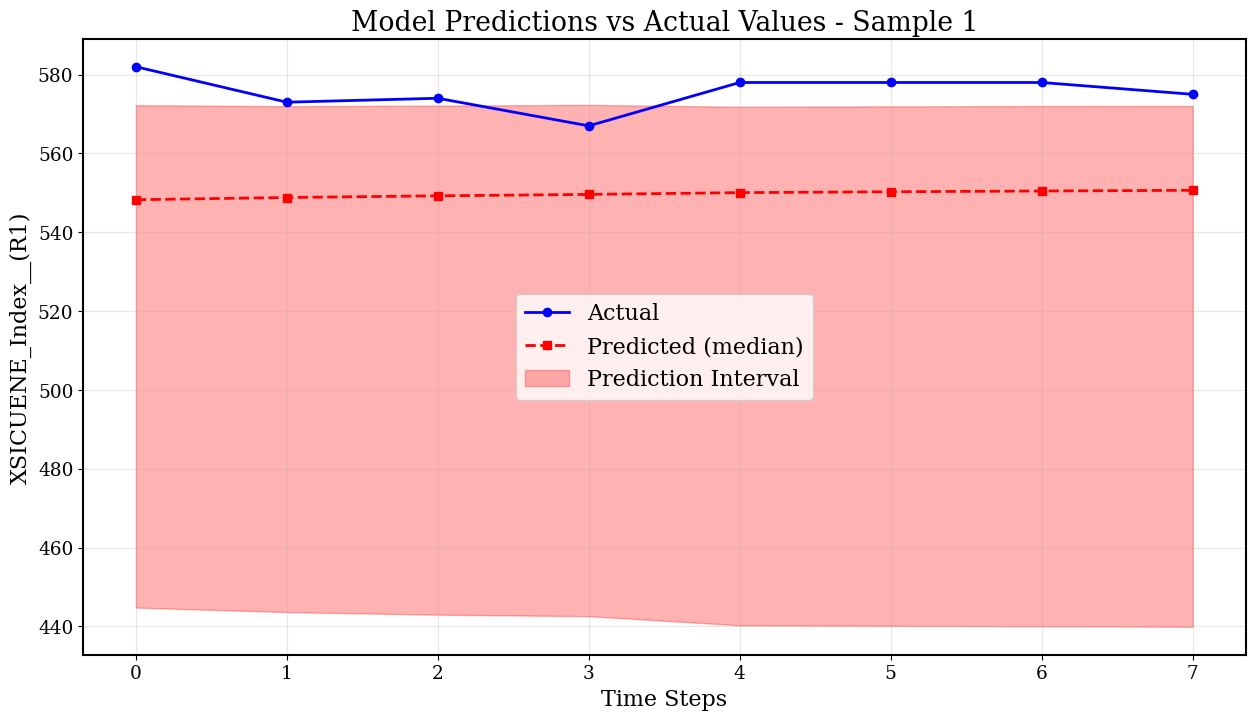

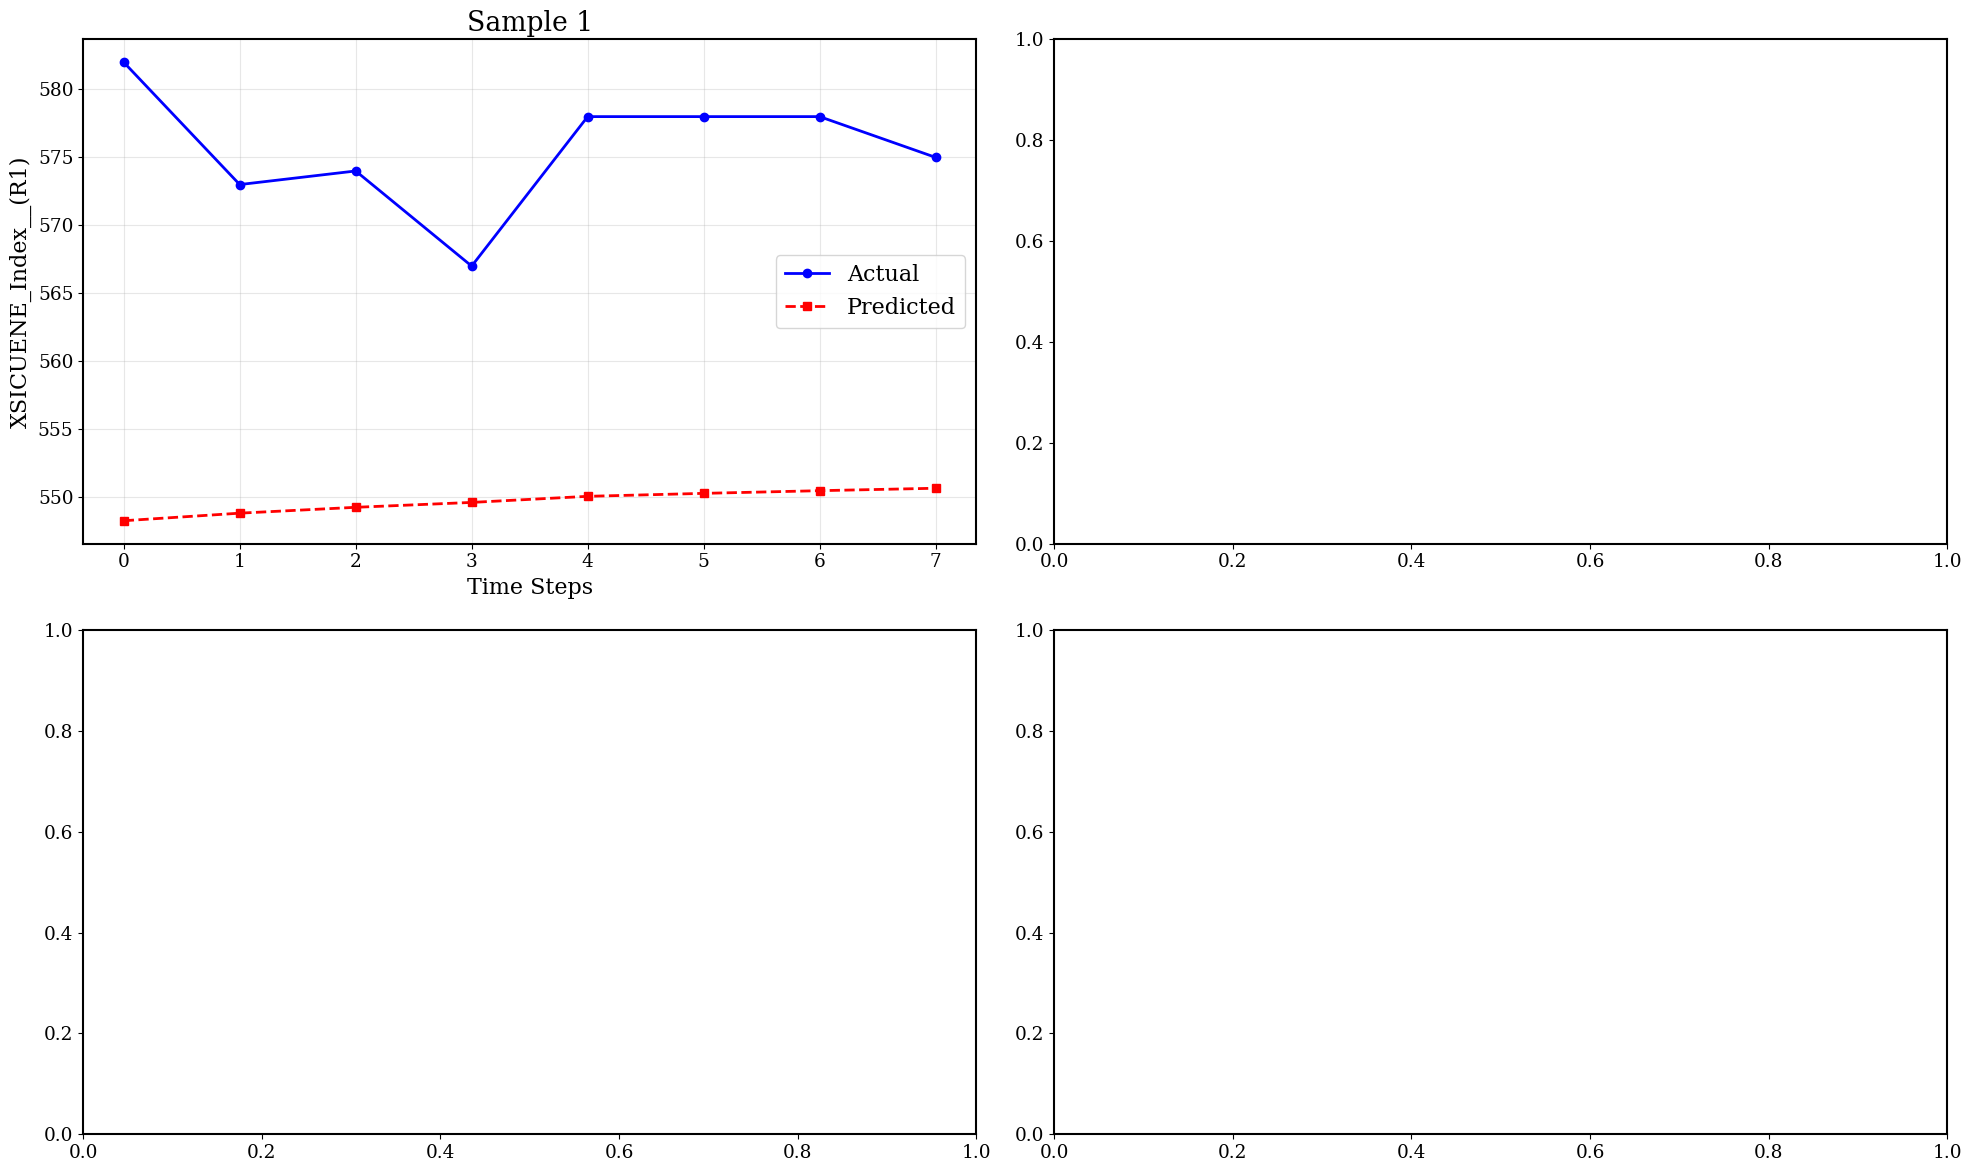


Model Performance Metrics for this batch:
Mean Absolute Error (MAE): 25.9494
Root Mean Square Error (RMSE): 26.3098
R² Score: -38.0319


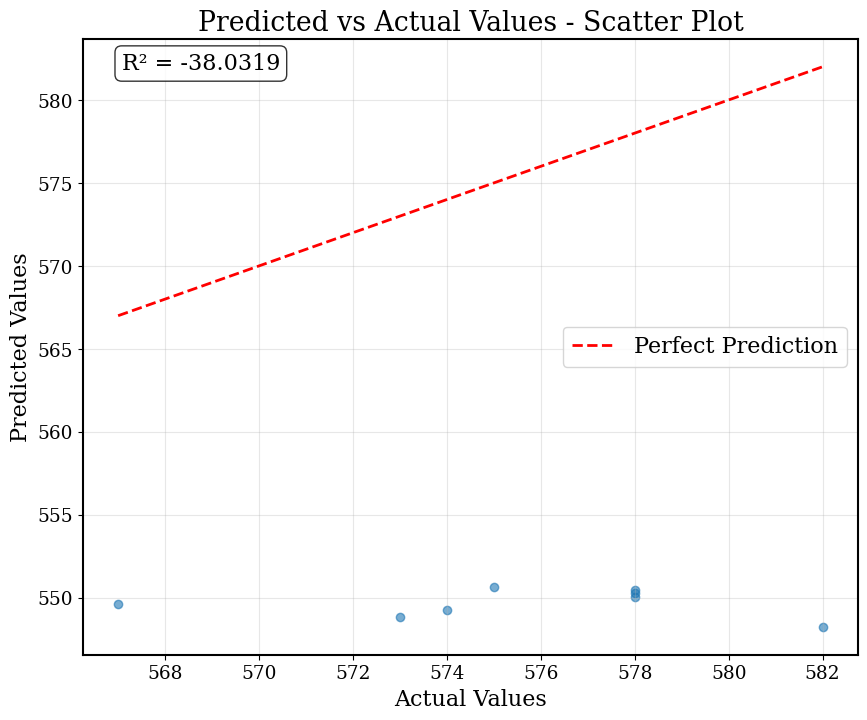

Processing multiple validation batches...
Total samples processed: 1
Prediction length: 8

Comprehensive Model Performance Metrics:
Mean Absolute Error (MAE): 25.9494
Root Mean Square Error (RMSE): 26.3098
R² Score: -38.0319


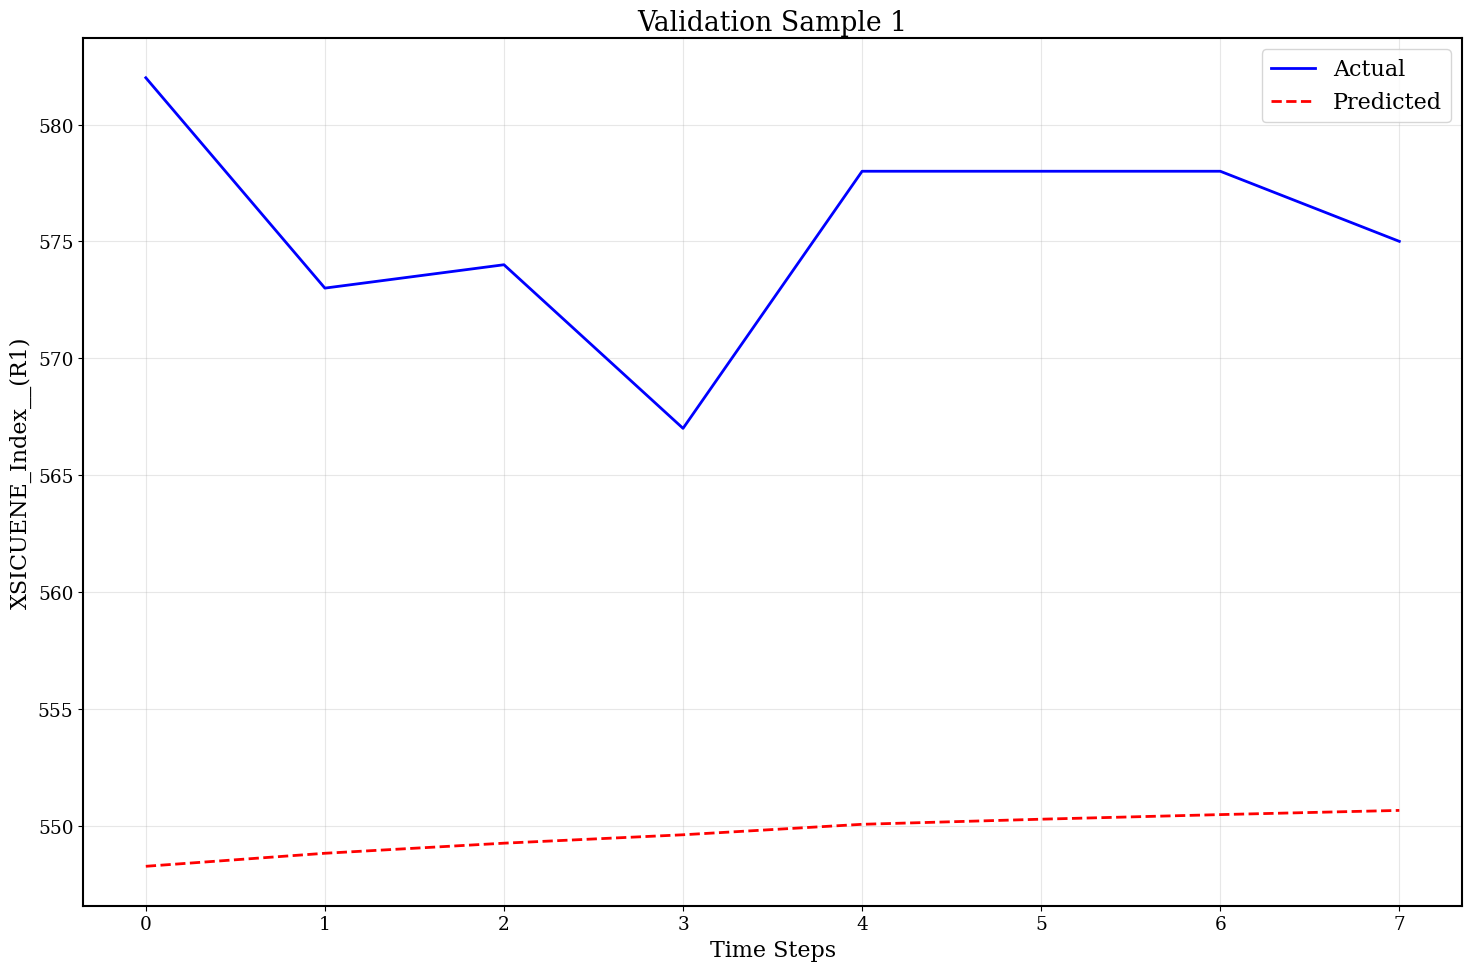

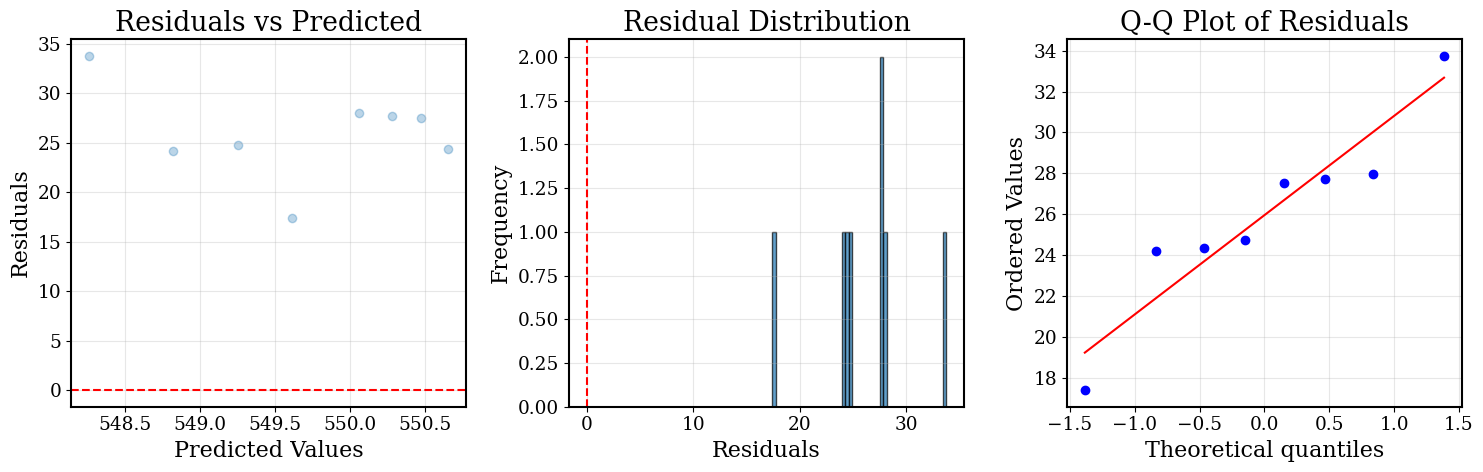

Residual statistics:
Mean: 25.949417
Std: 4.3398
Skewness: -0.2273
Kurtosis: 0.2064


In [ ]:
# Method 1: Simple and reliable prediction approach
# Get a batch from validation dataloader and make predictions
tft.eval()
with torch.no_grad():
    # Get a batch of data
    batch = next(iter(val_dataloader))
    x, y = batch  # x is input, y is target

    # Make predictions
    predictions = tft(x)

    print(f"Input shape: {x['encoder_cont'].shape}")  # (batch_size, encoder_length, features)
    print(f"Target shape: {y[0].shape}")  # (batch_size, prediction_length)
    print(f"Predictions shape: {predictions['prediction'].shape}")  # (batch_size, prediction_length, quantiles)

# Method 2: Plot first sample from batch
plt.figure(figsize=(15, 8))

# Get data for first sample in batch
sample_idx = 0
actual = y[0][sample_idx].cpu().numpy()  # actual values
pred_quantiles = predictions['prediction'][sample_idx].cpu().numpy()  # predicted quantiles

# Create time indices
time_indices = range(len(actual))

# Plot actual vs predicted (using median prediction - quantile index 3)
plt.plot(time_indices, actual, 'b-', label='Actual', linewidth=2, marker='o')
plt.plot(time_indices, pred_quantiles[:, 3], 'r--', label='Predicted (median)', linewidth=2, marker='s')

# Add confidence intervals (if available)
if pred_quantiles.shape[1] > 1:
    plt.fill_between(time_indices,
                     pred_quantiles[:, 1],  # lower quantile
                     pred_quantiles[:, 5],  # upper quantile
                     alpha=0.3, color='red', label='Prediction Interval')

plt.xlabel('Time Steps')
plt.ylabel(target_col)
plt.title('Model Predictions vs Actual Values - Sample 1')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Method 3: Plot multiple samples from the same batch
fig, axes = plt.subplots(2, 2, figsize=(20, 12))
axes = axes.flatten()

batch_size = min(4, len(y[0]))
for i in range(batch_size):
    ax = axes[i]

    actual = y[0][i].cpu().numpy()
    pred_quantiles = predictions['prediction'][i].cpu().numpy()
    time_indices = range(len(actual))

    ax.plot(time_indices, actual, 'b-', label='Actual', linewidth=2, marker='o')
    ax.plot(time_indices, pred_quantiles[:, 3], 'r--', label='Predicted', linewidth=2, marker='s')

    ax.set_title(f'Sample {i+1}')
    ax.set_xlabel('Time Steps')
    ax.set_ylabel(target_col)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Method 4: Calculate metrics for the batch
actual_all = y[0].cpu().numpy()  # (batch_size, prediction_length)
pred_all = predictions['prediction'][:, :, 3].cpu().numpy()  # median predictions

# Flatten for overall metrics
actual_flat = actual_all.flatten()
pred_flat = pred_all.flatten()

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(actual_flat, pred_flat)
rmse = np.sqrt(mean_squared_error(actual_flat, pred_flat))
r2 = r2_score(actual_flat, pred_flat)

print(f"\nModel Performance Metrics for this batch:")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Root Mean Square Error (RMSE): {rmse:.4f}")
print(f"R² Score: {r2:.4f}")

# Method 5: Scatter plot of predictions vs actuals
plt.figure(figsize=(10, 8))
plt.scatter(actual_flat, pred_flat, alpha=0.6)
plt.plot([actual_flat.min(), actual_flat.max()],
         [actual_flat.min(), actual_flat.max()],
         'r--', linewidth=2, label='Perfect Prediction')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Predicted vs Actual Values - Scatter Plot')
plt.legend()
plt.grid(True, alpha=0.3)

# Add R² to the plot
plt.text(0.05, 0.95, f'R² = {r2:.4f}', transform=plt.gca().transAxes,
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
plt.show()

# Method 6: Process multiple batches for more comprehensive evaluation
print("Processing multiple validation batches...")
all_actuals = []
all_predictions = []

tft.eval()
with torch.no_grad():
    for i, batch in enumerate(val_dataloader):
        if i >= 5:  # Process first 5 batches
            break

        x, y = batch
        predictions = tft(x)

        actual = y[0].cpu().numpy()  # (batch_size, prediction_length)
        pred = predictions['prediction'][:, :, 3].cpu().numpy()  # median predictions

        all_actuals.append(actual)
        all_predictions.append(pred)

# Combine all batches
all_actuals = np.concatenate(all_actuals, axis=0)
all_predictions = np.concatenate(all_predictions, axis=0)

print(f"Total samples processed: {all_actuals.shape[0]}")
print(f"Prediction length: {all_actuals.shape[1]}")

# Calculate comprehensive metrics
actual_comprehensive = all_actuals.flatten()
pred_comprehensive = all_predictions.flatten()

mae_comp = mean_absolute_error(actual_comprehensive, pred_comprehensive)
rmse_comp = np.sqrt(mean_squared_error(actual_comprehensive, pred_comprehensive))
r2_comp = r2_score(actual_comprehensive, pred_comprehensive)

print(f"\nComprehensive Model Performance Metrics:")
print(f"Mean Absolute Error (MAE): {mae_comp:.4f}")
print(f"Root Mean Square Error (RMSE): {rmse_comp:.4f}")
print(f"R² Score: {r2_comp:.4f}")

# Method 7: Time series visualization for multiple validation samples
plt.figure(figsize=(15, 10))

# Plot first few samples
n_samples_to_plot = min(3, all_actuals.shape[0])
for i in range(n_samples_to_plot):
    plt.subplot(n_samples_to_plot, 1, i+1)

    time_indices = range(all_actuals.shape[1])
    plt.plot(time_indices, all_actuals[i], 'b-', label='Actual', linewidth=2)
    plt.plot(time_indices, all_predictions[i], 'r--', label='Predicted', linewidth=2)

    plt.title(f'Validation Sample {i+1}')
    plt.xlabel('Time Steps')
    plt.ylabel(target_col)
    plt.legend()
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Method 8: Error distribution analysis
residuals = actual_comprehensive - pred_comprehensive

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.scatter(pred_comprehensive, residuals, alpha=0.3)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residuals vs Predicted')
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 2)
plt.hist(residuals, bins=50, edgecolor='black', alpha=0.7)
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.title('Residual Distribution')
plt.axvline(x=0, color='r', linestyle='--')
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 3)
from scipy import stats
stats.probplot(residuals, dist="norm", plot=plt)
plt.title('Q-Q Plot of Residuals')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Residual statistics:")
print(f"Mean: {np.mean(residuals):.6f}")
print(f"Std: {np.std(residuals):.4f}")
print(f"Skewness: {stats.skew(residuals):.4f}")
print(f"Kurtosis: {stats.kurtosis(residuals):.4f}")

In [31]:
batch = next(iter(train_dataloader))
yhat = tft(batch[0]) # Give dummy batch to forward().
make_dot(yhat, params=dict(list(tft.named_parameters()))).render("rnn_torchviz", format="svg")


'rnn_torchviz.svg'

In [114]:
out.prediction

tensor([[[-0.0305, -0.0202, -0.0068,  0.0076,  0.0007,  0.0161,  0.0180],
         [-0.0308, -0.0200, -0.0075,  0.0074,  0.0009,  0.0163,  0.0178],
         [-0.0310, -0.0199, -0.0078,  0.0074,  0.0010,  0.0166,  0.0178],
         [-0.0312, -0.0198, -0.0080,  0.0074,  0.0010,  0.0168,  0.0177],
         [-0.0314, -0.0201, -0.0079,  0.0077,  0.0005,  0.0170,  0.0176],
         [-0.0315, -0.0201, -0.0079,  0.0077,  0.0004,  0.0171,  0.0175],
         [-0.0315, -0.0200, -0.0078,  0.0077,  0.0003,  0.0172,  0.0175],
         [-0.0316, -0.0200, -0.0078,  0.0077,  0.0002,  0.0172,  0.0174]]])